# 00 — Exploratory Data Analysis

This notebook analyses the MedMNIST+ datasets to understand:
- Class distribution and imbalance
- Resolution and channel statistics
- Sample image grids for visual inspection

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from PIL import Image
from medical_mamba.data.constants import DATASET_META

## 1. Load and Inspect Datasets

In [12]:
import os
from PIL import Image
import numpy as np

# Set the root path to the dataset directory
DATASET_ROOT = Path("../dataset")

# Get list of datasets
datasets = ["bloodmnist_dataset", "dermamnist_dataset", "octmnist_dataset", "pathmnist_dataset"]

for dataset_name in datasets:
    dataset_path = DATASET_ROOT / dataset_name
    if not dataset_path.exists():
        print(f"⚠ {dataset_name} not found at {dataset_path}")
        continue
    
    # List train images
    train_path = dataset_path / "train"
    if train_path.exists():
        image_files = [f for f in os.listdir(train_path) if f.endswith('.png') or f.endswith('.jpg')]
        if image_files:
            # Load a sample image to get info
            sample_img = Image.open(train_path / image_files[0])
            print(f"\n{dataset_name.replace('_dataset', '')}:")
            print(f"  Shape: {sample_img.size[1]} x {sample_img.size[0]} x {len(sample_img.getbands())}")  
            print(f"  Train images: {len(image_files)}")
            print(f"  Sample image: {image_files[0]}")
        else:
            print(f"\n{dataset_name}: No images found in train folder")
    else:
        print(f"\n{dataset_name}: train folder not found")


bloodmnist:
  Shape: 224 x 224 x 3
  Train images: 11959
  Sample image: 0_7.png

dermamnist:
  Shape: 224 x 224 x 3
  Train images: 7007
  Sample image: 0_0.png

octmnist:
  Shape: 224 x 224 x 1
  Train images: 97477
  Sample image: 0_0.jpg

pathmnist:
  Shape: 224 x 224 x 3
  Train images: 89996
  Sample image: 0_0.png


## 2. Class Distribution

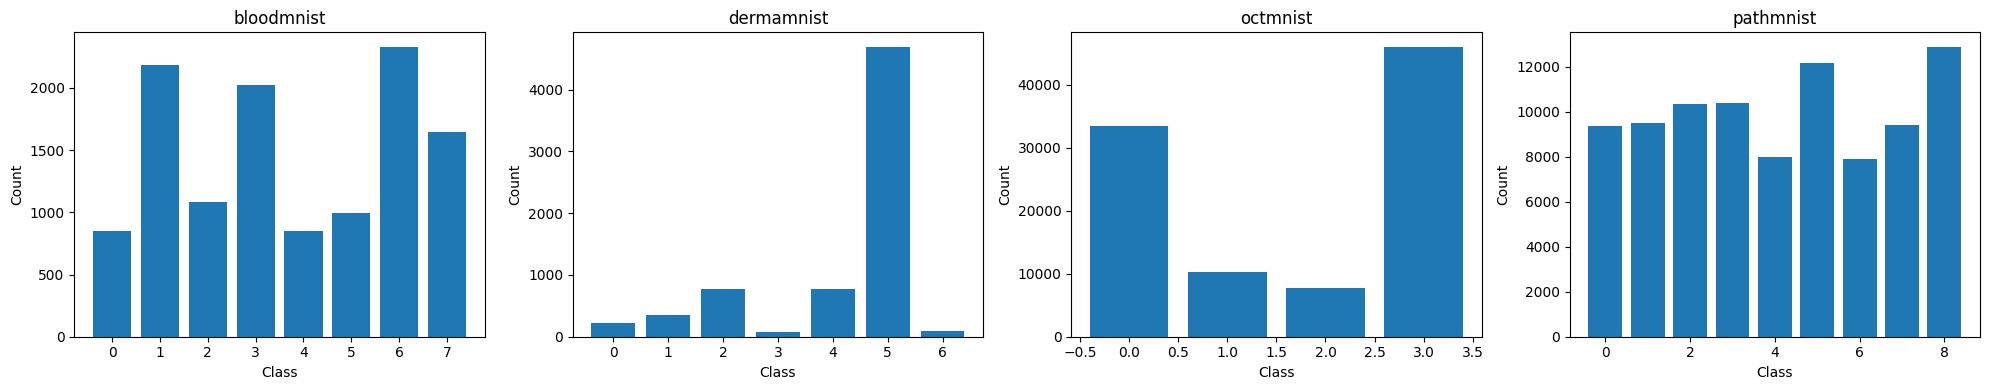

In [13]:
# Extract labels from filenames and count class distribution
from collections import Counter

DATASET_ROOT = Path("../dataset")
datasets = {
    "bloodmnist": ("bloodmnist_dataset", DATASET_META["bloodmnist"]["num_classes"]),
    "dermamnist": ("dermamnist_dataset", DATASET_META["dermamnist"]["num_classes"]),
    "octmnist": ("octmnist_dataset", DATASET_META["octmnist"]["num_classes"]),
    "pathmnist": ("pathmnist_dataset", DATASET_META["pathmnist"]["num_classes"]),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (ds_display_name, (ds_folder_name, num_classes)) in zip(axes, datasets.items()):
    dataset_path = DATASET_ROOT / ds_folder_name / "train"
    
    if not dataset_path.exists():
        ax.set_title(f"{ds_display_name} (missing)")
        continue
    
    image_files = [f for f in os.listdir(dataset_path) if f.endswith('.png') or f.endswith('.jpg')]
    
    # Extract labels from filenames (format: {index}_{label}.png)
    labels = []
    for img_file in image_files:
        try:
            label = int(img_file.split('_')[-1].split('.')[0])
            labels.append(label)
        except:
            pass
    
    if labels:
        # Count distribution
        counts = np.bincount(labels, minlength=num_classes)
        ax.bar(range(len(counts)), counts)
        ax.set_title(ds_display_name)
        ax.set_xlabel("Class")
        ax.set_ylabel("Count")
    else:
        ax.set_title(f"{ds_display_name} (no labels extracted)")

plt.tight_layout()
plt.show()

## 3. Sample Image Grids

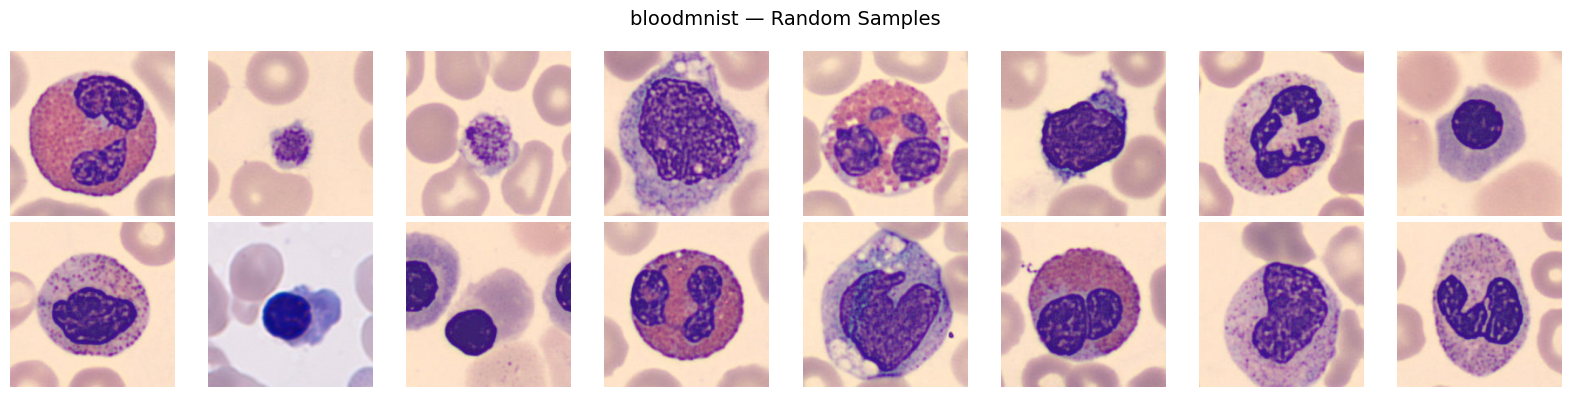

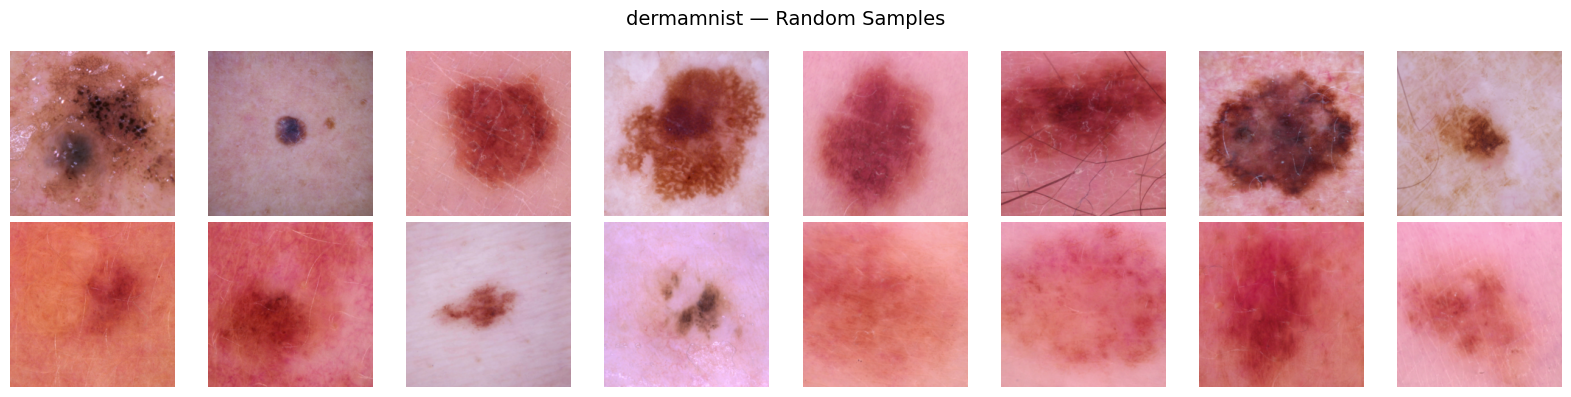

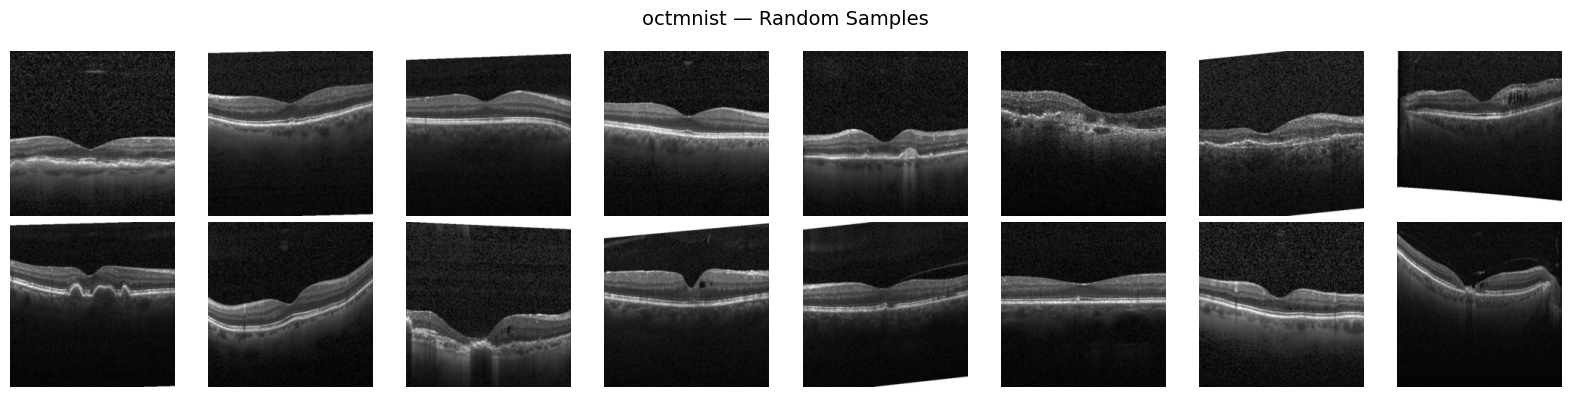

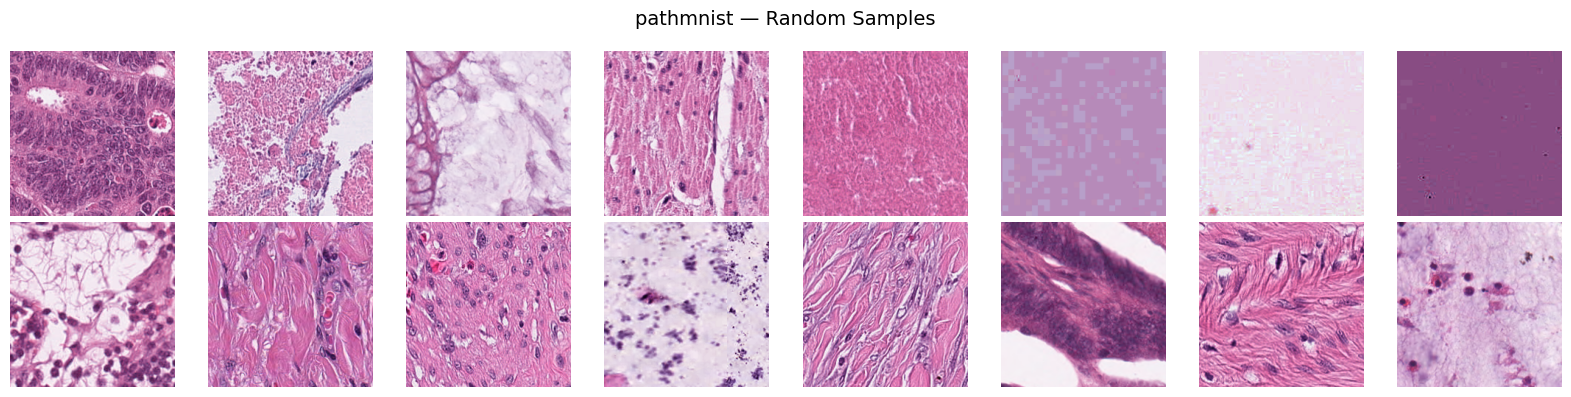

In [14]:
DATASET_ROOT = Path("../dataset")
datasets = ["bloodmnist_dataset", "dermamnist_dataset", "octmnist_dataset", "pathmnist_dataset"]

for ds_folder in datasets:
    dataset_path = DATASET_ROOT / ds_folder / "train"
    if not dataset_path.exists():
        continue
    
    image_files = [f for f in os.listdir(dataset_path) if f.endswith('.png') or f.endswith('.jpg')]
    if not image_files:
        continue
    
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    fig.suptitle(f"{ds_folder.replace('_dataset', '')} — Random Samples", fontsize=14)
    
    for i, ax in enumerate(axes.flat):
        img_file = np.random.choice(image_files)
        img_path = dataset_path / img_file
        img = Image.open(img_path)
        ax.imshow(img, cmap="gray" if img.mode == 'L' else None)
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()